<a href="https://colab.research.google.com/github/TurkayAydogan/ATAT/blob/Ver3/ATAT3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### 1. Google Drive'ı Bağlamak
Drive'daki `.py` dosyalarınızı modül olarak içe aktarmak veya `.ipynb` dosyalarınıza erişmek için en sağlam yöntem budur.

In [ ]:
#from google.colab import drive
#drive.mount('/content/drive')

# Daha sonra bir .py dosyasını içe aktarmak için yolu sistem yoluna ekleyebilirsiniz:
# import sys
# sys.path.append('/content/drive/MyDrive/klasor_adiniz')
# import dosyaniz

Mounted at /content/drive


### 2. Yerel Bilgisayardan Dosya Yüklemek
Kod ile bilgisayarınızdan dosya seçip yüklemek isterseniz:

In [ ]:
#from google.colab import files
#uploaded = files.upload()

# Yüklenen bir .py dosyasını çalıştırmak için:
# %run dosya_adi.py

### 3. GitHub'dan Proje Getirmek
Eğer tüm projeniz GitHub üzerindeyse:

In [ ]:
#!git clone https://github.com/kullanici_adi/repo_adi.git

Cloning into 'repo_adi'...
fatal: could not read Username for 'https://github.com': No such device or address


In [ ]:
# Tek bir dosyayı (ATAT2.ipynb) GitHub'dan indirmek için 'raw' linkini kullanmalıyız:
!wget https://raw.githubusercontent.com/TurkayAydogan/ATAT/Ver2/ATAT2.ipynb

print('\nDosya başarıyla indirildi. Sol taraftaki klasör simgesine tıklayarak görebilirsiniz.')

--2026-05-09 09:42:53--  https://raw.githubusercontent.com/TurkayAydogan/ATAT/Ver2/ATAT2.ipynb
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 96614 (94K) [text/plain]
Saving to: ‘ATAT2.ipynb’

ATAT2.ipynb         100%[===================>]  94.35K  --.-KB/s    in 0.003s  

2026-05-09 09:42:54 (34.6 MB/s) - ‘ATAT2.ipynb’ saved [96614/96614]


Dosya başarıyla indirildi. Sol taraftaki klasör simgesine tıklayarak görebilirsiniz.


In [ ]:
import subprocess
result = subprocess.run(['nvidia-smi'], capture_output=True, text=True)
print(result.stdout)
# Çıktıda "T4" veya "A100" görmelisiniz

Sat May  9 09:54:20 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   42C    P8             12W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:
!pip install "dask[dataframe]" xgboost lightgbm imbalanced-learn scikit-learn matplotlib seaborn -q
# k-NN ve Naive Bayes scikit-learn içinde geliyor, ekstra kurulum gerekmez

In [ ]:
# --- YENİ EKLENEN KÜTÜPHANELER ---
from sklearn.neighbors import KNeighborsClassifier         # k-NN (Uzaklık tabanlı)
from sklearn.naive_bayes import GaussianNB                 # Naive Bayes (Olasılık tabanlı)
from sklearn.cluster import KMeans                         # k-Means (Gözetimsiz Öğrenme)
from sklearn.decomposition import PCA                      # 2D Görselleştirme için
from sklearn.metrics import roc_curve, auc, roc_auc_score  # ROC ve AUC metrikleri
from sklearn.preprocessing import label_binarize           # ROC için sınıfları 0-1 yapma

print("✅ Yeni algoritmalar ve metrik kütüphaneleri projeye başarıyla dahil edildi!")

✅ Yeni algoritmalar ve metrik kütüphaneleri projeye başarıyla dahil edildi!


In [ ]:
from google.colab import drive
import dask.dataframe as dd
import pandas as pd
import numpy as np

# 1. Google Drive'a bağlanma
drive.mount('/content/drive')

print("\n1. Google Drive'dan veri Dask ile okunuyor...")
DATA_PATH = '/content/drive/MyDrive/CICIDS2017/*.csv'

df = dd.read_csv(
    DATA_PATH,
    assume_missing=True,
    dtype='object',
    on_bad_lines='skip'
)

# Sütun isimlerinin başındaki/sonundaki boşlukları temizle
df.columns = df.columns.str.strip()

# 2. Sayısal dönüşüm ve RAM tasarrufu için Downcasting (float64 -> float32)
print("2. Veri tipleri optimize ediliyor (RAM tasarrufu)...")
for col in df.columns:
    if col != 'Label':
        df[col] = dd.to_numeric(df[col], errors='coerce')

float_cols = [c for c in df.columns if c != 'Label']
for col in float_cols:
    df[col] = df[col].astype('float32')

# 3. Pandas'a geçiş (Hata aldığın df_pd işte burada oluşuyor!)
print("3. Dask'tan Pandas'a geçiliyor (Lütfen 1-2 dakika bekleyin)...")
df_pd = df.compute()

print(f"\n✅ İŞLEM TAMAM! Veri başarıyla RAM'e yüklendi.")
print(f"✅ Veri Boyutu (Shape): {df_pd.shape}")
print(f"✅ RAM Kullanımı: {df_pd.memory_usage(deep=True).sum() / 1e9:.2f} GB")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).

1. Google Drive'dan veri Dask ile okunuyor...
2. Veri tipleri optimize ediliyor (RAM tasarrufu)...
3. Dask'tan Pandas'a geçiliyor (Lütfen 1-2 dakika bekleyin)...

✅ İŞLEM TAMAM! Veri başarıyla RAM'e yüklendi.
✅ Veri Boyutu (Shape): (2830743, 79)
✅ RAM Kullanımı: 0.95 GB


In [ ]:
print("--- FAZ 3.1: Eksik Veri Temizliği (Imputation) ---")
# Verinin kopyasını alıyoruz ki orijinal Pandas DataFrame bozulmasın
df_clean = df_pd.copy()

# 1. Infinity (Sonsuzluk) değerlerini NaN'a çevir
df_clean.replace([np.inf, -np.inf], np.nan, inplace=True)

# 2. Tüm NaN değerleri kendi sütununun MEDYAN değeri ile doldur
numeric_cols = df_clean.select_dtypes(include=[np.number]).columns
df_clean[numeric_cols] = df_clean[numeric_cols].fillna(df_clean[numeric_cols].median())

print(f"✅ Temizlik sonrası kalan toplam NaN sayısı: {df_clean.isnull().sum().sum()}")
# Çıktının "0" olması gerekir.

--- FAZ 3.1: Eksik Veri Temizliği (Imputation) ---
✅ Temizlik sonrası kalan toplam NaN sayısı: 0


In [ ]:
import numpy as np
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

print("--- FAZ 3.2: Label Encoding ve Stratified Split ---")
le = LabelEncoder()
y = le.fit_transform(df_clean['Label'])
X = df_clean.drop('Label', axis=1).select_dtypes(include=[np.number])
class_names = le.classes_

# %80 Eğitim, %20 Test — Stratified olması çok önemli(az sınıflar her iki tarafa da gitsin)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)
print(f"Eğitim Seti Boyutu: {X_train.shape}")
print(f"Test Seti Boyutu: {X_test.shape}")

--- FAZ 3.2: Label Encoding ve Stratified Split ---
Eğitim Seti Boyutu: (2264594, 78)
Test Seti Boyutu: (566149, 78)


In [ ]:
import time
import pandas as pd
from sklearn.feature_selection import mutual_info_classif

print("--- FAZ 3.3: Öznitelik Seçimi (Correlation & Information Gain) ---")
print("Sütunlar eleniyor... (Lütfen 1-2 dakika bekleyin)")

# 1. Yüksek korelasyonlu sütunları ele
corr_matrix = pd.DataFrame(X_train).corr().abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
high_corr_cols = [col for col in upper.columns if any(upper[col] > 0.95)]
print(f"Silinen yüksek korelasyonlu sütun sayısı: {len(high_corr_cols)}")

X_train_corr = X_train.drop(columns=high_corr_cols)
X_test_corr  = X_test.drop(columns=high_corr_cols)

# 2. Information Gain ile en iyi 25 sütunu seç
t0 = time.time()
mi_scores = mutual_info_classif(X_train_corr, y_train, random_state=42)
print(f"✅ Information Gain hesaplama süresi: {time.time()-t0:.1f}s")

mi_series = pd.Series(mi_scores, index=X_train_corr.columns).sort_values(ascending=False)
selected_features = mi_series.head(25).index.tolist()

X_train_sel = X_train_corr[selected_features]
X_test_sel  = X_test_corr[selected_features]
print(f"✅ Nihai sütun sayısı 78'den {X_train_sel.shape[1]}'e düşürüldü.")

--- FAZ 3.3: Öznitelik Seçimi (Correlation & Information Gain) ---
Sütunlar eleniyor... (Lütfen 1-2 dakika bekleyin)
Silinen yüksek korelasyonlu sütun sayısı: 23
✅ Information Gain hesaplama süresi: 1050.4s
✅ Nihai sütun sayısı 78'den 25'e düşürüldü.


In [ ]:
from sklearn.preprocessing import MinMaxScaler

print("--- FAZ 3.4: Min-Max Normalizasyonu ---")
scaler = MinMaxScaler()

# Sadece Train setine FIT edilir, Test setine sadece TRANSFORM edilir (Data Leakage önlemi)
X_train_scaled = scaler.fit_transform(X_train_sel)
X_test_scaled  = scaler.transform(X_test_sel)

print(f"\n🎉 FAZ 3 KUSURSUZ TAMAMLANDI!")
print(f"Verilerin Minimum Değeri: {X_train_scaled.min():.2f}")
print(f"Verilerin Maksimum Değeri: {X_train_scaled.max():.2f}")

--- FAZ 3.4: Min-Max Normalizasyonu ---

🎉 FAZ 3 KUSURSUZ TAMAMLANDI!
Verilerin Minimum Değeri: 0.00
Verilerin Maksimum Değeri: 1.00


In [ ]:
from imblearn.over_sampling import SMOTE
from collections import Counter

print("--- FAZ 4: SMOTE ile Sınıf Dengeleme (RAM Korumalı) ---")

# 1. Eğitim setindeki mevcut sınıf sayılarını görelim
train_counts = Counter(y_train)
print("SMOTE Öncesi Kritik Azınlık Sınıfları (Eğitim Seti):")
for cls_id, cnt in sorted(train_counts.items()):
    if cnt < 1000: # Sadece 1000'den az olanları yazdır
        print(f"  {class_names[cls_id]}: {cnt} örnek")

# 2. k_neighbors değerini en az örneğe sahip sınıfa göre dinamik belirliyoruz
min_samples = min(train_counts.values())
k = min(5, min_samples - 1)
if k < 1: k = 1 # Kural: k en az 1 olmalı
print(f"\nDinamik k_neighbors değeri: {k}")

# 3. RAM Koruması: Her sınıfı maksimum 5000 örneğe tamamla (Çoğunluk sınıflarına dokunma)
# (Bu strateji RAM patlamasını önler ve modellerin azınlıkları öğrenmesi için yeterlidir)
strategy = {cls_id: max(cnt, 5000) for cls_id, cnt in train_counts.items()}

# 4. SMOTE Uygulaması
print("\nSMOTE uygulanıyor... (Lütfen 1-2 dakika bekleyin)")
t0 = time.time()
smote = SMOTE(sampling_strategy=strategy, k_neighbors=k, random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train_scaled, y_train)

print(f"✅ SMOTE Tamamlandı! Süre: {time.time()-t0:.1f}s")
print(f"Orijinal Eğitim Seti Boyutu: {X_train_scaled.shape}")
print(f"SMOTE Sonrası Eğitim Seti: {X_train_smote.shape}")

# SMOTE Sonrası kontrol
smote_counts = Counter(y_train_smote)
print("\nSMOTE Sonrası Kritik Sınıflar (Eğitim Seti):")
for cls_id, cnt in sorted(smote_counts.items()):
    if train_counts[cls_id] < 1000: # Eskiden az olanların yeni hali
        print(f"  {class_names[cls_id]}: {cnt} örnek (Eskiden: {train_counts[cls_id]})")

--- FAZ 4: SMOTE ile Sınıf Dengeleme (RAM Korumalı) ---
SMOTE Öncesi Kritik Azınlık Sınıfları (Eğitim Seti):
  Heartbleed: 9 örnek
  Infiltration: 29 örnek
  Web Attack � Sql Injection: 17 örnek
  Web Attack � XSS: 522 örnek

Dinamik k_neighbors değeri: 5

SMOTE uygulanıyor... (Lütfen 1-2 dakika bekleyin)
✅ SMOTE Tamamlandı! Süre: 0.7s
Orijinal Eğitim Seti Boyutu: (2264594, 25)
SMOTE Sonrası Eğitim Seti: (2292484, 25)

SMOTE Sonrası Kritik Sınıflar (Eğitim Seti):
  Heartbleed: 5000 örnek (Eskiden: 9)
  Infiltration: 5000 örnek (Eskiden: 29)
  Web Attack � Sql Injection: 5000 örnek (Eskiden: 17)
  Web Attack � XSS: 5000 örnek (Eskiden: 522)


In [ ]:
import time
from sklearn.metrics import classification_report
import xgboost as xgb
import lightgbm as lgb

print("--- FAZ 5.1: XGBoost ve LightGBM (Temiz+SMOTE Verisi ile) ---")

# XGBoost
t0 = time.time()
xgb_c = xgb.XGBClassifier(
    n_estimators=100, tree_method='hist', device='cuda',
    objective='multi:softmax', num_class=len(class_names),
    random_state=42, verbosity=0
)
xgb_c.fit(X_train_smote, y_train_smote)
pred_xgb_c = xgb_c.predict(X_test_scaled)
print(f"\n✅ XGBoost Bitti! Süre: {time.time()-t0:.1f}s")
print(classification_report(y_test, pred_xgb_c, target_names=class_names, zero_division=0))

# LightGBM
t0 = time.time()
lgbm_c = lgb.LGBMClassifier(n_estimators=100, random_state=42, n_jobs=-1, verbose=-1)
lgbm_c.fit(X_train_smote, y_train_smote)
pred_lgbm_c = lgbm_c.predict(X_test_scaled)
print(f"\n✅ LightGBM Bitti! Süre: {time.time()-t0:.1f}s")
print(classification_report(y_test, pred_lgbm_c, target_names=class_names, zero_division=0))

--- FAZ 5.1: XGBoost ve LightGBM (Temiz+SMOTE Verisi ile) ---

✅ XGBoost Bitti! Süre: 22.0s
                            precision    recall  f1-score   support

                    BENIGN       0.81      0.62      0.70    454620
                       Bot       0.00      0.00      0.00       393
                      DDoS       0.00      0.00      0.00     25606
             DoS GoldenEye       0.00      0.00      0.00      2059
                  DoS Hulk       0.10      0.01      0.01     46215
          DoS Slowhttptest       0.00      0.00      0.00      1100
             DoS slowloris       0.00      0.00      0.00      1159
               FTP-Patator       0.00      0.00      0.00      1588
                Heartbleed       0.00      0.00      0.00         2
              Infiltration       0.00      0.00      0.00         7
                  PortScan       0.16      1.00      0.28     31786
               SSH-Patator       0.00      0.00      0.00      1179
  Web Attack � Brute Fo

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(



✅ LightGBM Bitti! Süre: 330.5s
                            precision    recall  f1-score   support

                    BENIGN       0.86      0.83      0.85    454620
                       Bot       0.00      0.00      0.00       393
                      DDoS       0.00      0.00      0.00     25606
             DoS GoldenEye       0.00      0.00      0.00      2059
                  DoS Hulk       0.34      0.51      0.41     46215
          DoS Slowhttptest       0.22      0.05      0.08      1100
             DoS slowloris       0.00      0.00      0.00      1159
               FTP-Patator       0.00      0.00      0.00      1588
                Heartbleed       0.00      0.00      0.00         2
              Infiltration       0.00      0.00      0.00         7
                  PortScan       0.29      0.43      0.35     31786
               SSH-Patator       0.00      0.00      0.00      1179
  Web Attack � Brute Force       0.00      0.00      0.00       301
Web Attack � Sq

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression

print("--- FAZ 5.2: Random Forest ve Lojistik Regresyon (Temiz+SMOTE Verisi ile) ---")

# Random Forest
t0 = time.time()
rf_c = RandomForestClassifier(n_estimators=50, max_samples=0.3, n_jobs=-1, random_state=42)
rf_c.fit(X_train_smote, y_train_smote)
pred_rf_c = rf_c.predict(X_test_scaled)
print(f"\n✅ Random Forest Bitti! Süre: {time.time()-t0:.1f}s")
print(classification_report(y_test, pred_rf_c, target_names=class_names, zero_division=0))

# Lojistik Regresyon
t0 = time.time()
lr_c = LogisticRegression(max_iter=1000, multi_class='multinomial', n_jobs=-1, random_state=42)
lr_c.fit(X_train_smote, y_train_smote)
pred_lr_c = lr_c.predict(X_test_scaled)
print(f"\n✅ Lojistik Regresyon Bitti! Süre: {time.time()-t0:.1f}s")
print(classification_report(y_test, pred_lr_c, target_names=class_names, zero_division=0))

--- FAZ 5.2: Random Forest ve Lojistik Regresyon (Temiz+SMOTE Verisi ile) ---

✅ Random Forest Bitti! Süre: 192.3s
                            precision    recall  f1-score   support

                    BENIGN       1.00      1.00      1.00    454620
                       Bot       0.79      0.89      0.84       393
                      DDoS       1.00      1.00      1.00     25606
             DoS GoldenEye       1.00      0.99      0.99      2059
                  DoS Hulk       1.00      1.00      1.00     46215
          DoS Slowhttptest       0.99      0.99      0.99      1100
             DoS slowloris       0.99      0.99      0.99      1159
               FTP-Patator       1.00      1.00      1.00      1588
                Heartbleed       1.00      1.00      1.00         2
              Infiltration       1.00      0.86      0.92         7
                  PortScan       0.99      1.00      1.00     31786
               SSH-Patator       1.00      1.00      1.00      1179


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(



✅ Lojistik Regresyon Bitti! Süre: 676.1s
                            precision    recall  f1-score   support

                    BENIGN       0.91      0.98      0.95    454620
                       Bot       0.00      0.00      0.00       393
                      DDoS       0.97      0.72      0.82     25606
             DoS GoldenEye       0.79      0.52      0.63      2059
                  DoS Hulk       0.93      0.71      0.81     46215
          DoS Slowhttptest       0.63      0.19      0.29      1100
             DoS slowloris       0.81      0.18      0.30      1159
               FTP-Patator       0.00      0.00      0.00      1588
                Heartbleed       0.20      1.00      0.33         2
              Infiltration       0.02      0.43      0.04         7
                  PortScan       0.69      0.42      0.52     31786
               SSH-Patator       0.00      0.00      0.00      1179
  Web Attack � Brute Force       0.00      0.00      0.00       301
Web A

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
import numpy as np

print("--- FAZ 5.3: k-NN ve Naive Bayes (Temiz+SMOTE Verisi ile) ---")

# Naive Bayes (Olasılık tabanlı)
t0 = time.time()
nb_c = GaussianNB()
nb_c.fit(X_train_smote, y_train_smote)
pred_nb_c = nb_c.predict(X_test_scaled)
print(f"\n✅ Naive Bayes Bitti! Süre: {time.time()-t0:.1f}s")
print(classification_report(y_test, pred_nb_c, target_names=class_names, zero_division=0))

# k-NN (Uzaklık tabanlı - Test seti hızlandırma amacıyla örneklendi)
print("\n⏳ k-NN çalışıyor... (Uzaklık hesabı maliyetli olduğu için test seti 20.000 örneğe indirgendi)")
np.random.seed(42)
sample_indices = np.random.choice(len(X_test_scaled), size=20000, replace=False)
X_test_knn = X_test_scaled[sample_indices]
y_test_knn = y_test[sample_indices]

t0 = time.time()
knn_c = KNeighborsClassifier(n_neighbors=5, n_jobs=-1)
knn_c.fit(X_train_smote, y_train_smote)
pred_knn_c = knn_c.predict(X_test_knn)
print(f"✅ k-NN Bitti! Süre: {time.time()-t0:.1f}s")
print(classification_report(y_test_knn, pred_knn_c, target_names=class_names, zero_division=0))

--- FAZ 5.3: k-NN ve Naive Bayes (Temiz+SMOTE Verisi ile) ---

✅ Naive Bayes Bitti! Süre: 2.4s
                            precision    recall  f1-score   support

                    BENIGN       1.00      0.23      0.37    454620
                       Bot       0.00      0.46      0.00       393
                      DDoS       0.95      0.62      0.75     25606
             DoS GoldenEye       0.14      0.92      0.24      2059
                  DoS Hulk       0.87      0.66      0.75     46215
          DoS Slowhttptest       0.02      0.07      0.03      1100
             DoS slowloris       0.17      0.55      0.26      1159
               FTP-Patator       0.66      1.00      0.79      1588
                Heartbleed       1.00      1.00      1.00         2
              Infiltration       0.00      0.86      0.00         7
                  PortScan       0.24      0.99      0.39     31786
               SSH-Patator       0.33      0.99      0.49      1179
  Web Attack � Brute

ValueError: Number of classes, 13, does not match size of target_names, 15. Try specifying the labels parameter

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report
import numpy as np
import time

print("--- FAZ 5.4 (AKILLI ÖRNEKLEME, k-NN için çözüm): k-NN ---")
print("⏳ k-NN çalışıyor... (Her sınıftan zorunlu örneklem ALINDI, toplam 20.000 örnek)")

np.random.seed(42)

# 1. AŞAMA: Senin Fikrin -> Her sınıftan (özellikle az olanlardan) kesinlikle örnek al
guaranteed_indices = []
for cls in np.unique(y_test):
    cls_indices = np.where(y_test == cls)[0]
    # Sınıfta 5'ten az örnek varsa hepsini al, çoksa rastgele 5 tanesini kesin al ki torbada bulunsun
    n_take = min(len(cls_indices), 5)
    guaranteed_indices.extend(np.random.choice(cls_indices, n_take, replace=False))

# 2. AŞAMA: 20.000'e tamamlamak için geriye kalanları tamamen rastgele seç
remaining_needed = 20000 - len(guaranteed_indices)
# Zaten aldıklarımızı bir daha almamak için listeden çıkarıyoruz
all_other_indices = np.setdiff1d(np.arange(len(y_test)), guaranteed_indices)
random_fill_indices = np.random.choice(all_other_indices, remaining_needed, replace=False)

# 3. AŞAMA: İkisini birleştir, sırayı karıştır ve akıllı test setini oluştur
final_indices = np.concatenate([guaranteed_indices, random_fill_indices])
np.random.shuffle(final_indices)

X_test_knn = X_test_scaled[final_indices]
y_test_knn = y_test[final_indices]

# Model Eğitimi ve Tahmin
t0 = time.time()
knn_c = KNeighborsClassifier(n_neighbors=5, n_jobs=-1)
knn_c.fit(X_train_smote, y_train_smote)
pred_knn_c = knn_c.predict(X_test_knn)

print(f"\n✅ k-NN Bitti! Süre: {time.time()-t0:.1f}s")
print(classification_report(y_test_knn, pred_knn_c, target_names=class_names, zero_division=0))

--- FAZ 5.4 (AKILLI ÖRNEKLEME, k-NN için çözüm): k-NN ---
⏳ k-NN çalışıyor... (Her sınıftan zorunlu örneklem ALINDI, toplam 20.000 örnek)

✅ k-NN Bitti! Süre: 262.2s
                            precision    recall  f1-score   support

                    BENIGN       1.00      0.99      1.00     16018
                       Bot       0.77      0.74      0.76        23
                      DDoS       1.00      1.00      1.00       920
             DoS GoldenEye       0.97      1.00      0.99        67
                  DoS Hulk       1.00      1.00      1.00      1622
          DoS Slowhttptest       0.97      1.00      0.99        35
             DoS slowloris       1.00      1.00      1.00        44
               FTP-Patator       1.00      0.99      0.99        74
                Heartbleed       1.00      1.00      1.00         2
              Infiltration       1.00      0.80      0.89         5
                  PortScan       0.93      0.95      0.94      1109
               SS

In [ ]:
from sklearn.utils.class_weight import compute_sample_weight
import xgboost as xgb
import lightgbm as lgb
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
import time
from sklearn.metrics import classification_report

print("--- FAZ 6: Deney D — Class Weight ile Dengeleme (SMOTE Alternatifi) ---")

# SMOTE YOK! Sadece Faz 3'ten gelen 25 sütunluk temiz veriyi kullanıyoruz.
# Sınıf ağırlıklarını hesaplıyoruz (Makine az olan sınıflara matematiksel ceza puanı verecek)
sample_weights = compute_sample_weight(class_weight='balanced', y=y_train)

# ── XGBoost (sample_weight ile) ──
t0=time.time()
xgb_d = xgb.XGBClassifier(
    n_estimators=100, tree_method='hist', device='cuda',
    objective='multi:softmax', num_class=len(class_names),
    random_state=42, verbosity=0
)
# Dikkat: XGBoost class_weight parametresi almaz, fit içine sample_weight verilir!
xgb_d.fit(X_train_scaled, y_train, sample_weight=sample_weights)
pred_xgb_d = xgb_d.predict(X_test_scaled)
print(f"\n✅ XGBoost (Class Weight) Bitti! Süre: {time.time()-t0:.1f}s")
print(classification_report(y_test, pred_xgb_d, target_names=class_names, zero_division=0))

# ── LightGBM (class_weight='balanced' ile) ──
t0=time.time()
lgbm_d = lgb.LGBMClassifier(
    n_estimators=100, class_weight='balanced',
    random_state=42, n_jobs=-1, verbose=-1
)
lgbm_d.fit(X_train_scaled, y_train)
pred_lgbm_d = lgbm_d.predict(X_test_scaled)
print(f"\n✅ LightGBM (Class Weight) Bitti! Süre: {time.time()-t0:.1f}s")
print(classification_report(y_test, pred_lgbm_d, target_names=class_names, zero_division=0))

# ── Random Forest (class_weight='balanced' ile) ──
t0=time.time()
rf_d = RandomForestClassifier(
    n_estimators=50, max_samples=0.3, class_weight='balanced',
    n_jobs=-1, random_state=42
)
rf_d.fit(X_train_scaled, y_train)
pred_rf_d = rf_d.predict(X_test_scaled)
print(f"\n✅ Random Forest (Class Weight) Bitti! Süre: {time.time()-t0:.1f}s")
print(classification_report(y_test, pred_rf_d, target_names=class_names, zero_division=0))

# ── Lojistik Regresyon (class_weight='balanced' ile) ──
t0=time.time()
lr_d = LogisticRegression(
    max_iter=1000, multi_class='multinomial', class_weight='balanced',
    n_jobs=-1, random_state=42
)
lr_d.fit(X_train_scaled, y_train)
pred_lr_d = lr_d.predict(X_test_scaled)
print(f"\n✅ Lojistik Regresyon (Class Weight) Bitti! Süre: {time.time()-t0:.1f}s")
print(classification_report(y_test, pred_lr_d, target_names=class_names, zero_division=0))

--- FAZ 6: Deney D — Class Weight ile Dengeleme (SMOTE Alternatifi) ---

✅ XGBoost (Class Weight) Bitti! Süre: 38.1s
                            precision    recall  f1-score   support

                    BENIGN       1.00      1.00      1.00    454620
                       Bot       0.67      0.99      0.80       393
                      DDoS       1.00      1.00      1.00     25606
             DoS GoldenEye       0.98      1.00      0.99      2059
                  DoS Hulk       1.00      1.00      1.00     46215
          DoS Slowhttptest       0.98      0.99      0.99      1100
             DoS slowloris       0.98      1.00      0.99      1159
               FTP-Patator       1.00      1.00      1.00      1588
                Heartbleed       1.00      1.00      1.00         2
              Infiltration       1.00      1.00      1.00         7
                  PortScan       0.99      1.00      1.00     31786
               SSH-Patator       1.00      1.00      1.00      117

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(



✅ LightGBM (Class Weight) Bitti! Süre: 444.3s
                            precision    recall  f1-score   support

                    BENIGN       0.99      0.55      0.71    454620
                       Bot       0.02      0.79      0.04       393
                      DDoS       0.88      0.52      0.66     25606
             DoS GoldenEye       0.04      0.92      0.07      2059
                  DoS Hulk       0.38      0.86      0.53     46215
          DoS Slowhttptest       0.07      0.72      0.13      1100
             DoS slowloris       0.13      0.75      0.22      1159
               FTP-Patator       0.14      0.97      0.25      1588
                Heartbleed       0.01      1.00      0.01         2
              Infiltration       0.00      0.86      0.00         7
                  PortScan       0.57      0.35      0.44     31786
               SSH-Patator       0.06      0.42      0.11      1179
  Web Attack � Brute Force       0.00      0.00      0.00       301


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(



✅ Lojistik Regresyon (Class Weight) Bitti! Süre: 1042.0s
                            precision    recall  f1-score   support

                    BENIGN       1.00      0.55      0.71    454620
                       Bot       0.01      0.90      0.01       393
                      DDoS       0.86      0.95      0.90     25606
             DoS GoldenEye       0.47      0.93      0.62      2059
                  DoS Hulk       0.83      0.69      0.76     46215
          DoS Slowhttptest       0.19      0.84      0.31      1100
             DoS slowloris       0.10      0.82      0.18      1159
               FTP-Patator       0.03      0.68      0.07      1588
                Heartbleed       0.40      1.00      0.57         2
              Infiltration       0.00      0.86      0.01         7
                  PortScan       0.64      0.87      0.74     31786
               SSH-Patator       0.05      0.99      0.09      1179
  Web Attack � Brute Force       0.00      0.06      0.01

--- FAZ 7.1: Confusion Matrix (Karmaşıklık Matrisi) ---


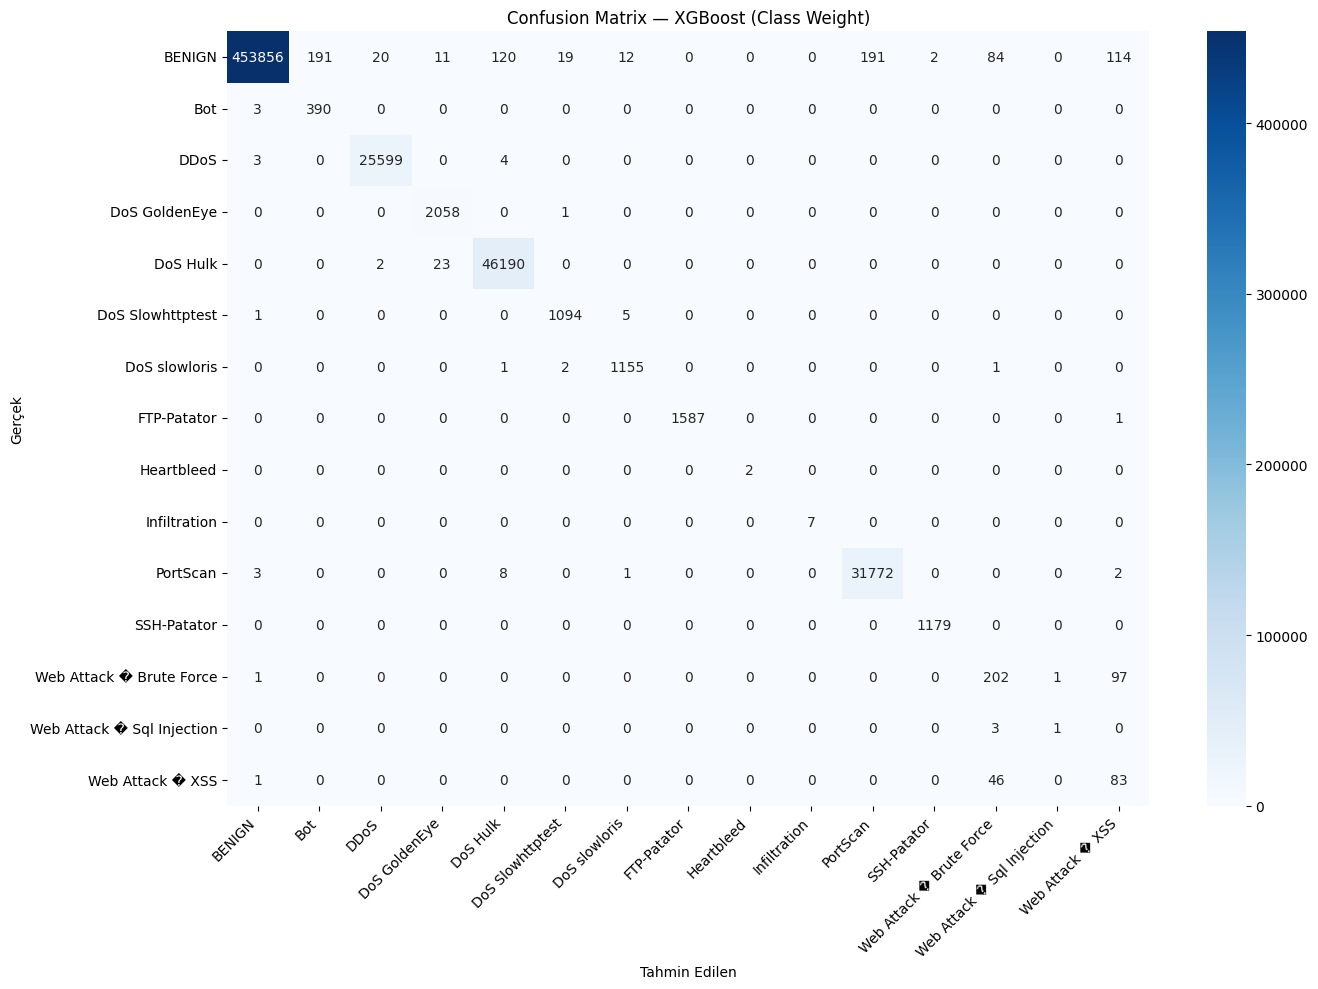

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

print("--- FAZ 7.1: Confusion Matrix (Karmaşıklık Matrisi) ---")

# Şampiyon modelimizin tahminlerini seçiyoruz
best_pred = pred_xgb_d
best_label = "XGBoost (Class Weight)"

cm = confusion_matrix(y_test, best_pred)
plt.figure(figsize=(14,10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Tahmin Edilen')
plt.ylabel('Gerçek')
plt.title(f'Confusion Matrix — {best_label}')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150)
plt.show()

--- FAZ 7.2: ROC Eğrisi ve AUC Karşılaştırması ---


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


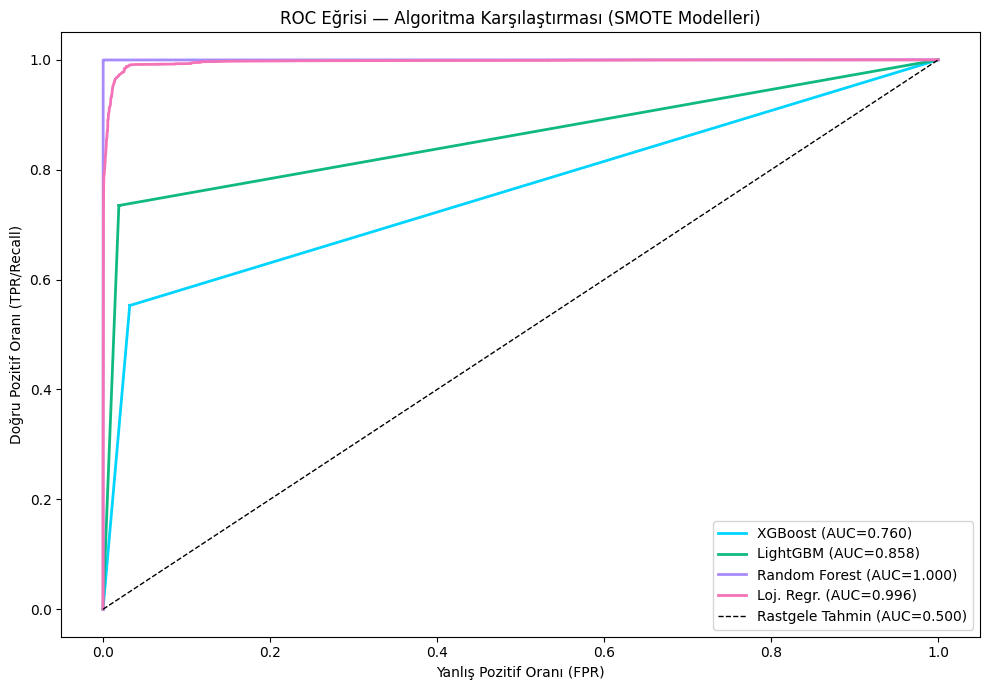

In [ ]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt
import numpy as np

print("--- FAZ 7.2: ROC Eğrisi ve AUC Karşılaştırması ---")

# ROC eğrisi predict_proba (olasılık tahmini) gerektirir.
# SMOTE ile eğittiğimiz en güçlü 4 modelimizi (Faz 5'ten) seçiyoruz.
# k-NN'i dışarıda bırakıyoruz çünkü predict_proba hesabı çok ciddi bir zaman alır.
roc_models = {
    'XGBoost': xgb_c,
    'LightGBM': lgbm_c,
    'Random Forest': rf_c,
    'Loj. Regr.': lr_c,
}

# Çok sınıflı ROC için sınıfları 0-1 matrisine çeviriyoruz (One-vs-Rest stratejisi)
y_test_bin = label_binarize(y_test, classes=np.arange(len(class_names)))

plt.figure(figsize=(10, 7))
colors = ['#00d4ff', '#10b981', '#a78bfa', '#f472b6']

for (name, model), color in zip(roc_models.items(), colors):
    # Modelin olasılık tahminlerini al
    y_score = model.predict_proba(X_test_scaled)

    # Macro-average ROC (tüm sınıfların ortalaması)
    fpr, tpr, _ = roc_curve(y_test_bin.ravel(), y_score.ravel())
    roc_auc = auc(fpr, tpr)

    plt.plot(fpr, tpr, color=color, lw=2, label=f'{name} (AUC={roc_auc:.3f})')

# Şans eseri tahmin çizgisi (Rastgele atarsak AUC=0.5 olur)
plt.plot([0, 1], [0, 1], 'k--', lw=1, label='Rastgele Tahmin (AUC=0.500)')
plt.xlabel('Yanlış Pozitif Oranı (FPR)')
plt.ylabel('Doğru Pozitif Oranı (TPR/Recall)')
plt.title('ROC Eğrisi — Algoritma Karşılaştırması (SMOTE Modelleri)')
plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig('roc_curve.png', dpi=150)
plt.show()

--- FAZ 7.2b: ŞAMPİYONLARIN SAVAŞI (ROC Eğrisi) ---


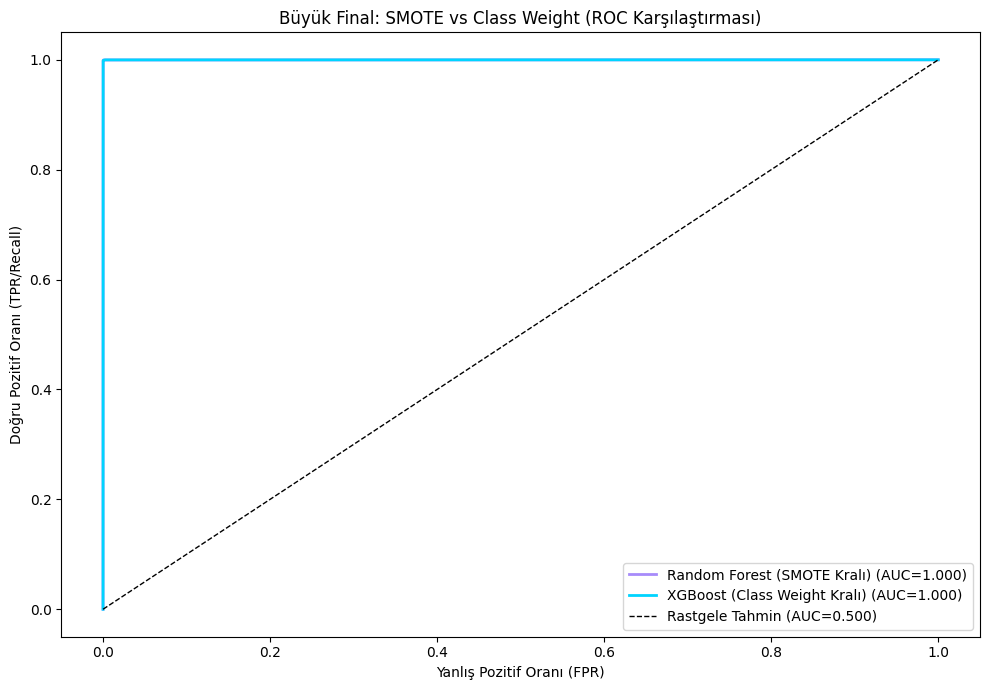

In [ ]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt
import numpy as np

print("--- FAZ 7.2b: ŞAMPİYONLARIN SAVAŞI (ROC Eğrisi) ---")

# Sadece iki mutlak şampiyonumuzu arenaya alıyoruz!
champions = {
    'Random Forest (SMOTE Kralı)': rf_c,
    'XGBoost (Class Weight Kralı)': xgb_d,
}

y_test_bin = label_binarize(y_test, classes=np.arange(len(class_names)))

plt.figure(figsize=(10, 7))
colors = ['#a78bfa', '#00d4ff'] # Mor ve Mavi

for (name, model), color in zip(champions.items(), colors):
    # Modelin olasılık tahminlerini al
    y_score = model.predict_proba(X_test_scaled)

    # Macro-average ROC
    fpr, tpr, _ = roc_curve(y_test_bin.ravel(), y_score.ravel())
    roc_auc = auc(fpr, tpr)

    plt.plot(fpr, tpr, color=color, lw=2, label=f'{name} (AUC={roc_auc:.3f})')

plt.plot([0, 1], [0, 1], 'k--', lw=1, label='Rastgele Tahmin (AUC=0.500)')
plt.xlabel('Yanlış Pozitif Oranı (FPR)')
plt.ylabel('Doğru Pozitif Oranı (TPR/Recall)')
plt.title('Büyük Final: SMOTE vs Class Weight (ROC Karşılaştırması)')
plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig('roc_curve_champions.png', dpi=150)
plt.show()

In [ ]:
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb
import time

print("--- FAZ 7.3: k-Fold Cross Validation (5-Fold) ---")

# k-Fold işlemini tüm modellerde yapmak saatler sürer.
# Bu yüzden sadece en iyi modelimiz olan Random Forest ve rekabetçi XGBoost'u seçiyoruz.
# NOT: İşlem süresini makul tutmak için temizlenmiş/ölçeklenmiş Orijinal Veri (SMOTE'suz) kullanıyoruz.

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_models = {
    'Random Forest': RandomForestClassifier(n_estimators=50, max_samples=0.3, n_jobs=-1, random_state=42),
    'XGBoost': xgb.XGBClassifier(n_estimators=100, tree_method='hist', device='cuda',
                                 objective='multi:softmax', num_class=len(class_names), verbosity=0, random_state=42)
}

for name, model in cv_models.items():
    t0 = time.time()
    print(f"\n⏳ {name} için 5-Fold CV hesaplanıyor... (Lütfen bekleyin)")

    # n_jobs=-1 ile tüm işlemci çekirdeklerini kullanıyoruz
    scores = cross_val_score(model, X_train_scaled, y_train, cv=cv, scoring='f1_macro', n_jobs=-1)

    print(f"✅ {name} — 5-Fold CV Macro F1 Sonuçları:")
    print(f"  Her bir fold (parça) skoru: {[f'{s:.3f}' for s in scores]}")
    print(f"  Ortalama Başarı: {scores.mean():.3f} ± {scores.std():.3f} (Standart Sapma)")
    print(f"  Geçen Süre: {time.time()-t0:.1f}s")

--- FAZ 7.3: k-Fold Cross Validation (5-Fold) ---

⏳ Random Forest için 5-Fold CV hesaplanıyor... (Lütfen bekleyin)
✅ Random Forest — 5-Fold CV Macro F1 Sonuçları:
  Her bir fold (parça) skoru: ['0.838', '0.868', '0.833', '0.794', '0.721']
  Ortalama Başarı: 0.811 ± 0.050 (Standart Sapma)
  Geçen Süre: 710.4s

⏳ XGBoost için 5-Fold CV hesaplanıyor... (Lütfen bekleyin)


/usr/local/lib/python3.12/dist-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


✅ XGBoost — 5-Fold CV Macro F1 Sonuçları:
  Her bir fold (parça) skoru: ['0.677', '0.694', '0.350', '0.050', '0.506']
  Ortalama Başarı: 0.455 ± 0.238 (Standart Sapma)
  Geçen Süre: 128.9s
